# FinLend: Análise estatística da inadimplência

## Resumo

- A inadimplência aumentou **1,16 pp** entre 2014 e 2015.
- A participação de Grades D/E **caiu 2,07 pp** no mesmo período.
- A deterioração ocorreu **dentro de D/E** e também nas demais grades.
- Após ajuste por grade e perfil observado, a safra 2015 manteve odds cerca de
  **27% maiores** (resultado associativo, não causal).
- Recalibrar: Underwriting e Pricing — não apenas restringir D/E.


## 1. Pergunta de negócio, hipóteses e escopo

O Head de Risco afirma que a inadimplência sobe porque a empresa aprova muitos
empréstimos de Grade D e E. Avalio três hipóteses:

1. a inadimplência aumentou entre 2014 e 2015;
2. a participação de D/E aumentou;
3. o risco dentro de D/E e das demais grades também mudou.

Restringi a análise a empréstimos de **36 meses** originados em **2014–2015**,
com desfecho conhecido. Essas safras estavam praticamente resolvidas no snapshot
de dezembro de 2018; safras mais recentes teriam poucos contratos resolvidos e
poderiam distorcer a inadimplência final. Entao manter a mesma coorte do dashboard
evita que a análise estatística e o Self-Service BI usem denominadores diferentes.

Fonte: camada Gold (`analysis_cohort.parquet`).


In [1]:
%matplotlib inline

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportions_ztest

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

GOLD_FILE = PROJECT_ROOT / "data" / "gold" / "analysis_cohort.parquet"
FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
TABLES_DIR = PROJECT_ROOT / "outputs" / "tables"

if not GOLD_FILE.exists():
    raise FileNotFoundError(
        f"Gold dataset not found: {GOLD_FILE}. "
        "Run the notebook from the project root or notebooks directory."
    )

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
TABLES_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (10, 4.5)
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

df = pd.read_parquet(GOLD_FILE)
assert df["loan_id"].is_unique
assert df["default_flag"].isin([0, 1]).all()
df["period"] = np.where(df["issue_year"] == 2014, "2014", "2015")
early = df[df["period"] == "2014"]
late = df[df["period"] == "2015"]

print(f"Contratos: {len(df):,}")
print(f"Inadimplentes: {int(df['default_flag'].sum()):,}")
print(f"Taxa de inadimplência: {100 * df['default_flag'].mean():.2f}%")


Contratos: 445,596
Inadimplentes: 64,447
Taxa de inadimplência: 14.46%


## 2. Análise exploratória

Comparei a evolução trimestral da inadimplência com a participação de D/E e, em
seguida, o risco dentro de cada grupo de grade. A pergunta prática é simples: a
carteira ficou mais concentrada em D/E, ou o risco piorou dentro das faixas já
existentes?


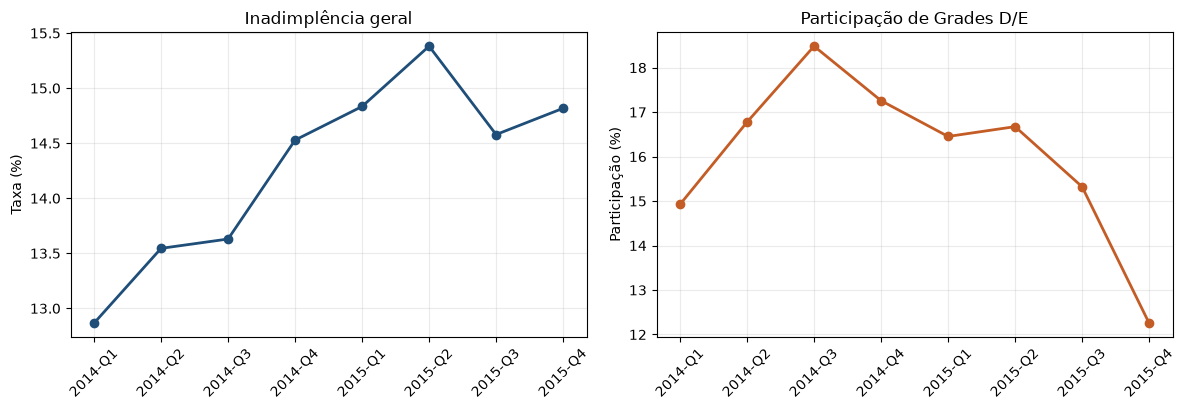

In [2]:
quarterly = (
    df.groupby("issue_quarter", as_index=False)
    .agg(
        total_loans=("loan_id", "size"),
        default_rate=("default_flag", "mean"),
        grade_de_share=("is_grade_de", "mean"),
    )
)
de_rates = (
    df.groupby(["issue_quarter", "is_grade_de"], as_index=False)
    .agg(default_rate=("default_flag", "mean"))
    .pivot(index="issue_quarter", columns="is_grade_de", values="default_rate")
    .rename(columns={False: "other_default_rate", True: "de_default_rate"})
    .reset_index()
)
quarterly = quarterly.merge(de_rates, on="issue_quarter")
quarterly["default_rate_pct"] = 100 * quarterly["default_rate"]
quarterly["grade_de_share_pct"] = 100 * quarterly["grade_de_share"]
quarterly["de_default_rate_pct"] = 100 * quarterly["de_default_rate"]
quarterly["other_default_rate_pct"] = 100 * quarterly["other_default_rate"]
quarterly.to_csv(TABLES_DIR / "eda_quarterly_metrics.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2), sharex=True)
axes[0].plot(
    quarterly["issue_quarter"],
    quarterly["default_rate_pct"],
    marker="o",
    color="#1f4e79",
    linewidth=2,
)
axes[0].set_title("Inadimplência geral")
axes[0].set_ylabel("Taxa (%)")
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(
    quarterly["issue_quarter"],
    quarterly["grade_de_share_pct"],
    marker="o",
    color="#c45c26",
    linewidth=2,
)
axes[1].set_title("Participação de Grades D/E")
axes[1].set_ylabel("Participação (%)")
axes[1].tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "01_default_vs_de_share.png", dpi=150, bbox_inches="tight")
plt.show()


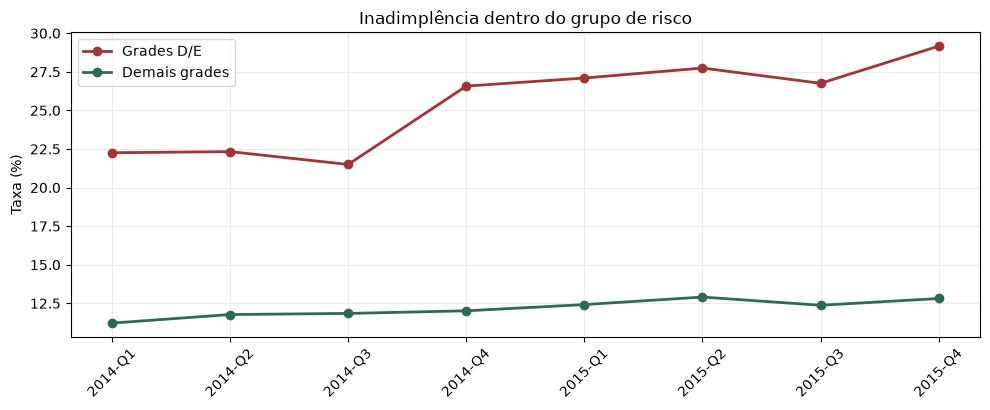

,share_2014_pct,share_2015_pct,default_2014_pct,default_2015_pct,delta_default_pp
grade,,,,,
A,21.7300,24.7700,5.3800,5.4200,0.0400
B,32.8800,32.4100,10.7200,11.9000,1.1700
C,27.0900,27.3600,17.1900,19.4400,2.2500
D,12.6200,11.5600,22.1700,26.2200,4.0500
E,4.3500,3.3400,27.0300,32.8400,5.8100
F,1.2200,0.4800,29.4900,42.4000,12.9000
G,0.1100,0.0900,36.3100,46.1200,9.8100


In [3]:
fig, ax = plt.subplots(figsize=(10, 4.2))
ax.plot(
    quarterly["issue_quarter"],
    quarterly["de_default_rate_pct"],
    marker="o",
    label="Grades D/E",
    color="#a63232",
    linewidth=2,
)
ax.plot(
    quarterly["issue_quarter"],
    quarterly["other_default_rate_pct"],
    marker="o",
    label="Demais grades",
    color="#2f6b4f",
    linewidth=2,
)
ax.set_title("Inadimplência dentro do grupo de risco")
ax.set_ylabel("Taxa (%)")
ax.tick_params(axis="x", rotation=45)
ax.legend()
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "02_default_within_grade_groups.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()

default_by_grade = (
    df.groupby(["period", "grade"], as_index=False)
    .agg(
        default_rate=("default_flag", "mean"),
        avg_interest_rate=("interest_rate_pct", "mean"),
        avg_dti=("debt_to_income_ratio", "mean"),
        total_loans=("loan_id", "size"),
    )
)
share_by_grade = (
    df.groupby(["period", "grade"])
    .size()
    .div(df.groupby("period").size())
    .rename("portfolio_share")
    .reset_index()
)
grade_summary = default_by_grade.merge(share_by_grade, on=["period", "grade"])
wide = grade_summary.pivot(index="grade", columns="period")

eda_grade = pd.DataFrame(
    {
        "share_2014_pct": 100 * wide[("portfolio_share", "2014")],
        "share_2015_pct": 100 * wide[("portfolio_share", "2015")],
        "default_2014_pct": 100 * wide[("default_rate", "2014")],
        "default_2015_pct": 100 * wide[("default_rate", "2015")],
        "rate_2014_pct": wide[("avg_interest_rate", "2014")],
        "rate_2015_pct": wide[("avg_interest_rate", "2015")],
        "dti_2014": wide[("avg_dti", "2014")],
        "dti_2015": wide[("avg_dti", "2015")],
    }
).reindex(list("ABCDEFG"))
eda_grade["delta_default_pp"] = (
    eda_grade["default_2015_pct"] - eda_grade["default_2014_pct"]
)
eda_grade["delta_rate_pp"] = (
    eda_grade["rate_2015_pct"] - eda_grade["rate_2014_pct"]
)
eda_grade.to_csv(TABLES_DIR / "eda_grade_period_comparison.csv")
eda_grade[
    [
        "share_2014_pct",
        "share_2015_pct",
        "default_2014_pct",
        "default_2015_pct",
        "delta_default_pp",
    ]
].round(2)


Entre 2014-Q1 e 2015-Q4, a inadimplência sobe enquanto a participação de D/E cai.
O risco aumenta dentro de D/E e também nas demais grades; em quase todas as grades,
2015 fica acima de 2014. O mecanismo “aprovamos muitos D/E” já aparece frágil na EDA.


## 3. Testes de hipótese e decomposição

Testes z de proporções (2015 vs 2014, α = 0,05). Como esses não
quantificam quanto da alta veio do mix versus da piora dentro dos grupos e
também uma decomposição sequencial da variação da taxa total (composição com taxas
de 2014; efeitos internos com participações de 2015).


In [4]:
def proportion_test(success_a, n_a, success_b, n_b, alternative="larger"):
    # Two-sample z-test for proportions. Group A vs group B.
    stat, pvalue = proportions_ztest(
        count=[success_a, success_b],
        nobs=[n_a, n_b],
        alternative=alternative,
    )
    return {
        "rate_2015": success_a / n_a,
        "rate_2014": success_b / n_b,
        "delta_pp": 100 * (success_a / n_a - success_b / n_b),
        "z_stat": stat,
        "p_value": pvalue,
    }


tests = pd.DataFrame(
    [
        {
            "hipotese": "H1 — inadimplência geral aumentou",
            **proportion_test(
                late["default_flag"].sum(),
                len(late),
                early["default_flag"].sum(),
                len(early),
                alternative="larger",
            ),
            "conclusao": "Sim — aumento detectável",
        },
        {
            "hipotese": "H2 — participação de D/E mudou",
            **proportion_test(
                late["is_grade_de"].sum(),
                len(late),
                early["is_grade_de"].sum(),
                len(early),
                alternative="two-sided",
            ),
            "conclusao": "Mudou — queda detectável",
        },
        {
            "hipotese": "H3 — inadimplência em D/E aumentou",
            **proportion_test(
                late.loc[late["is_grade_de"], "default_flag"].sum(),
                int(late["is_grade_de"].sum()),
                early.loc[early["is_grade_de"], "default_flag"].sum(),
                int(early["is_grade_de"].sum()),
                alternative="larger",
            ),
            "conclusao": "Sim — aumento detectável",
        },
        {
            "hipotese": "H4 — inadimplência nas demais grades aumentou",
            **proportion_test(
                late.loc[~late["is_grade_de"], "default_flag"].sum(),
                int((~late["is_grade_de"]).sum()),
                early.loc[~early["is_grade_de"], "default_flag"].sum(),
                int((~early["is_grade_de"]).sum()),
                alternative="larger",
            ),
            "conclusao": "Sim — aumento detectável",
        },
    ]
)
tests.to_csv(TABLES_DIR / "hypothesis_tests.csv", index=False)
tests.assign(
    rate_2015=lambda d: (100 * d["rate_2015"]).round(2),
    rate_2014=lambda d: (100 * d["rate_2014"]).round(2),
    delta_pp=lambda d: d["delta_pp"].round(2),
    z_stat=lambda d: d["z_stat"].round(2),
    p_value=lambda d: d["p_value"].map(lambda p: f"{p:.2e}"),
)[
    [
        "hipotese",
        "delta_pp",
        "z_stat",
        "p_value",
        "conclusao",
    ]
]


,hipotese,delta_pp,z_stat,p_value,conclusao
0,H1 — inadimplência geral aumentou,1.1600,10.6000,1.55e-26,Sim — aumento detectável
1,H2 — participação de D/E mudou,-2.0700,-18.3000,9.06e-75,Mudou — queda detectável
2,H3 — inadimplência em D/E aumentou,4.2800,12.6100,9.35e-37,Sim — aumento detectável
3,H4 — inadimplência nas demais grades aumentou,0.9000,8.0300,5.07e-16,Sim — aumento detectável


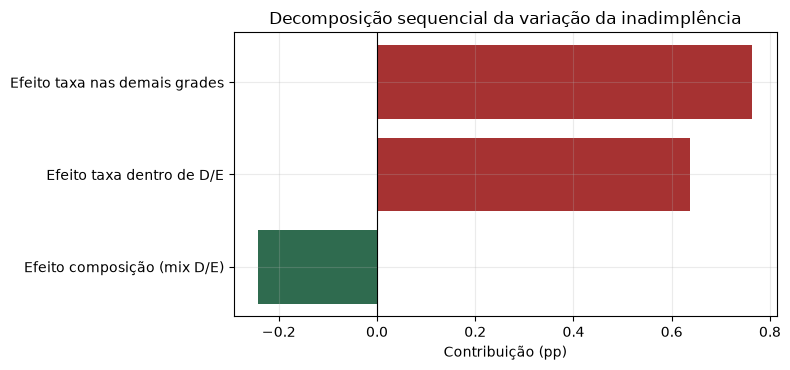

,component,pp
0,Variação total (2015 − 2014),1.1600
1,Efeito composição (mix D/E),-0.2410
2,Efeito taxa dentro de D/E,0.6380
3,Efeito taxa nas demais grades,0.7630
4,Soma dos efeitos,1.1600


In [5]:
s14 = early["is_grade_de"].mean()
s15 = late["is_grade_de"].mean()
p_de_14 = early.loc[early["is_grade_de"], "default_flag"].mean()
p_de_15 = late.loc[late["is_grade_de"], "default_flag"].mean()
p_ot_14 = early.loc[~early["is_grade_de"], "default_flag"].mean()
p_ot_15 = late.loc[~late["is_grade_de"], "default_flag"].mean()
r14 = early["default_flag"].mean()
r15 = late["default_flag"].mean()

composition = (s15 - s14) * (p_de_14 - p_ot_14)
rate_de = s15 * (p_de_15 - p_de_14)
rate_other = (1 - s15) * (p_ot_15 - p_ot_14)

decomp = pd.DataFrame(
    [
        {"component": "Variação total (2015 − 2014)", "pp": 100 * (r15 - r14)},
        {"component": "Efeito composição (mix D/E)", "pp": 100 * composition},
        {"component": "Efeito taxa dentro de D/E", "pp": 100 * rate_de},
        {"component": "Efeito taxa nas demais grades", "pp": 100 * rate_other},
        {
            "component": "Soma dos efeitos",
            "pp": 100 * (composition + rate_de + rate_other),
        },
    ]
)
decomp.to_csv(TABLES_DIR / "sequential_decomposition.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 3.8))
plot_df = decomp.iloc[1:4].copy()
colors = ["#2f6b4f" if v < 0 else "#a63232" for v in plot_df["pp"]]
ax.barh(plot_df["component"], plot_df["pp"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Contribuição (pp)")
ax.set_title("Decomposição sequencial da variação da inadimplência")
fig.tight_layout()
fig.savefig(
    FIGURES_DIR / "03_sequential_decomposition.png",
    dpi=150,
    bbox_inches="tight",
)
plt.show()
decomp.round(3)


Os resultados não sustentam a explicação de que a alta ocorreu porque a participação
de D/E cresceu: o mix caiu, enquanto a inadimplência subiu dentro de D/E e nas demais
grades. Isso aponta para uma deterioração mais ampla da qualidade das safras. Na
decomposição, os efeitos internos somam cerca de **+1,40 pp**, acima da alta total de
**+1,16 pp**; a mudança favorável do mix mitigou aproximadamente **0,24 pp**.


## 4. Regressão ajustada e insight não óbvio

Foi estimado um modelo de regressão logística, adequado ao desfecho binário de inadimplência. O primeiro modelo controla apenas por grade; o segundo acrescenta DTI, FICO, renda e juros. Em seguida, examino se a deterioração dentro das grades foi acompanhada por ajuste proporcional da precificação.


In [6]:
model_df = df.dropna(
    subset=[
        "default_flag",
        "debt_to_income_ratio",
        "fico_score_avg",
        "annual_income",
        "interest_rate_pct",
        "grade",
    ]
).copy()
model_df["late"] = (model_df["period"] == "2015").astype(int)
model_df["log_income"] = np.log1p(model_df["annual_income"])

logit_basic = smf.logit(
    "default_flag ~ late + C(grade)",
    data=model_df,
).fit(disp=False)

logit_full = smf.logit(
    "default_flag ~ late + C(grade) + debt_to_income_ratio"
    " + fico_score_avg + log_income + interest_rate_pct",
    data=model_df,
).fit(disp=False)


def odds_ratio_row(model, label):
    coef = model.params["late"]
    se = model.bse["late"]
    return {
        "modelo": label,
        "odds_ratio_2015": np.exp(coef),
        "or_ci95_low": np.exp(coef - 1.96 * se),
        "or_ci95_high": np.exp(coef + 1.96 * se),
        "p_value_display": f"{model.pvalues['late']:.2e}",
        "pseudo_r2": model.prsquared,
        "n_obs": int(model.nobs),
    }


logit_results = pd.DataFrame(
    [
        odds_ratio_row(logit_basic, "Somente grade"),
        odds_ratio_row(logit_full, "Grade + controles"),
    ]
)
logit_results.to_csv(TABLES_DIR / "logit_vintage_effect.csv", index=False)

print(
    "Após ajuste pelas características observadas, os empréstimos de 2015 "
    "apresentaram odds de inadimplência aproximadamente "
    f"{100 * (logit_results.loc[1, 'odds_ratio_2015'] - 1):.0f}% maiores "
    f"(OR={logit_results.loc[1, 'odds_ratio_2015']:.2f}; "
    f"IC95% {logit_results.loc[1, 'or_ci95_low']:.2f}–"
    f"{logit_results.loc[1, 'or_ci95_high']:.2f}). "
    "O modelo é associativo, não causal, e pode haver variáveis não observadas."
)

logit_results.round(
    {
        "odds_ratio_2015": 3,
        "or_ci95_low": 3,
        "or_ci95_high": 3,
        "pseudo_r2": 4,
    }
)


Após ajuste pelas características observadas, os empréstimos de 2015 apresentaram odds de inadimplência aproximadamente 27% maiores (OR=1.27; IC95% 1.25–1.29). O modelo é associativo, não causal, e pode haver variáveis não observadas.


,modelo,odds_ratio_2015,or_ci95_low,or_ci95_high,p_value_display,pseudo_r2,n_obs
0,Somente grade,1.1690,1.1480,1.1900,2.34e-65,0.0527,445594
1,Grade + controles,1.2700,1.2450,1.2950,9.55e-128,0.0610,445594


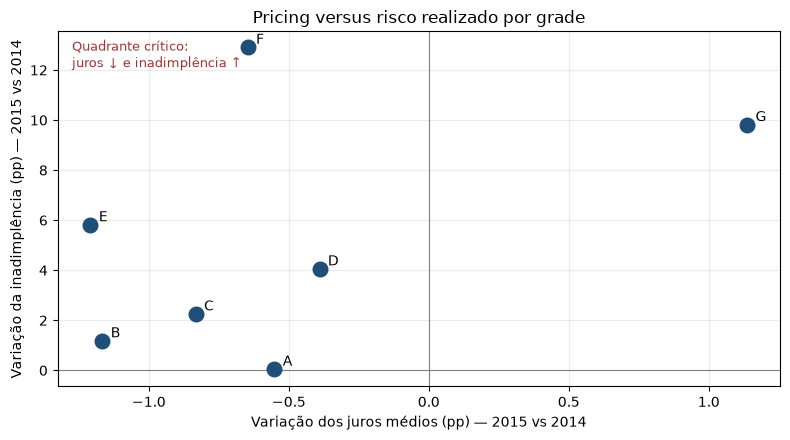

DTI 30+: participação 7.2% → 10.7%; inadimplência 19.6% → 21.0%.


In [ ]:
pricing = eda_grade[
    ["delta_default_pp", "delta_rate_pp", "dti_2014", "dti_2015"]
].copy()
pricing["delta_dti"] = pricing["dti_2015"] - pricing["dti_2014"]
pricing.to_csv(TABLES_DIR / "pricing_vs_risk_by_grade.csv")

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.axhline(0, color="grey", linewidth=0.8)
ax.axvline(0, color="grey", linewidth=0.8)
ax.scatter(
    pricing["delta_rate_pp"],
    pricing["delta_default_pp"],
    s=110,
    color="#1f4e79",
    zorder=3,
)
for grade, row in pricing.iterrows():
    ax.annotate(
        grade,
        (row["delta_rate_pp"] + 0.03, row["delta_default_pp"] + 0.15),
    )
ax.set_xlabel("Variação dos juros médios (pp) — 2015 vs 2014")
ax.set_ylabel("Variação da inadimplência (pp) — 2015 vs 2014")
ax.set_title("Pricing versus risco realizado por grade")
ax.text(
    0.02,
    0.98,
    "Quadrante de Atenção:\njuros ↓ e inadimplência ↑",
    transform=ax.transAxes,
    va="top",
    fontsize=9,
    color="#a63232",
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "04_pricing_vs_risk.png", dpi=150, bbox_inches="tight")
plt.show()

dti_shift = (
    df.groupby(["period", "dti_band"], as_index=False)
    .agg(
        portfolio_share=("loan_id", "size"),
        default_rate=("default_flag", "mean"),
    )
)
totals = dti_shift.groupby("period")["portfolio_share"].transform("sum")
dti_shift["portfolio_share_pct"] = 100 * dti_shift["portfolio_share"] / totals
dti_shift["default_rate_pct"] = 100 * dti_shift["default_rate"]
dti_shift = dti_shift[dti_shift["dti_band"] != "Unknown"]
dti_shift.to_csv(TABLES_DIR / "dti_band_shift.csv", index=False)

dti_30 = dti_shift[dti_shift["dti_band"] == "30+"].set_index("period")
print(
    "DTI 30+: participação "
    f"{dti_30.loc['2014', 'portfolio_share_pct']:.1f}% → "
    f"{dti_30.loc['2015', 'portfolio_share_pct']:.1f}%; "
    "inadimplência "
    f"{dti_30.loc['2014', 'default_rate_pct']:.1f}% → "
    f"{dti_30.loc['2015', 'default_rate_pct']:.1f}%."
)


A deterioração ocorreu dentro das grades, com aumento de DTI e sem aumento
proporcional dos juros. Em B–F, a inadimplência de 2015 sobe enquanto os juros médios
caem; a faixa DTI 30+ passa de **7,2%** para **10,7%** da carteira, com inadimplência
de **19,6%** para **21,0%**. O padrão sugere desalinhamento entre pricing e risco
realizado, sem provar que a precificação tenha causado a inadimplência.

## 5. Recomendação ao negócio

1. **Recalibrar regras de aprovação** — olhar o risco dentro das grades, não apenas o
   volume de D/E.
2. **Monitorar DTI alto** — a faixa 30+ cresceu e concentra inadimplência elevada.
3. **Revisar pricing em B–F**, com prioridade para C/D/E, onde risco subiu e juros caíram.
4. **Acompanhar default dentro da grade** e o gap preço×risco no dashboard, além do mix D/E.


## 6. Limitações

- A análise é observacional e identifica associações, não relações causais.
- O escopo está restrito a empréstimos de 36 meses originados em 2014–2015 e com
  desfecho conhecido.
- Grade e taxa de juros são fortemente relacionadas; seus coeficientes no modelo
  ajustado não devem ser lidos isoladamente como efeitos causais.
- Mudanças macroeconômicas, operacionais ou de política de crédito não observadas
  podem explicar parte do efeito associado à safra de 2015.


## Uso de ferramentas de IA

Foi utilizada uma ferramenta assistida por IA GPT-5.6 Sol, no Cursor para acelerar a estruturação
inicial do código, a organização do notebook e a revisão de linguagem. O escopo
analítico, as definições das métricas, os métodos estatísticos, a validação dos
resultados e as conclusões finais foram revisados e aprovados pelo autor.
